In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/reusable_codes')

from euler import euler


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# <u>Euler’s Method
</u>$$
\frac{dy}{dt} = f(t, y)
$$
with an initial condition $ y(t_0) = y_0 $.

### General Euler Formula
$$
y_{n+1} = y_n + \Delta t \, f(t_n, y_n)
$$

###<u> Single-Species Radioactive Decay</u>

For radioactive decay, the governing equation is:
$$
\frac{dN}{dt} = -\frac{N}{\tau}
$$

Applying Euler’s method:
$$
N_{n+1} = N_n + \Delta t \left(-\frac{N_n}{\tau}\right)
$$

This gives the numerical approximation for the number of undecayed particles at successive time steps.


### Coupled Decay System

For the two-species system:
$$
\frac{dN_A}{dt} = -\frac{N_A}{\tau_A} + \frac{N_B}{\tau_B}
$$
$$
\frac{dN_B}{dt} = \frac{N_A}{\tau_A} - \frac{N_B}{\tau_B}
$$

Applying Euler’s method:
$$
N_A^{n+1}
= N_A^n + \Delta t
\left(-\frac{N_A^n}{\tau_A} + \frac{N_B^n}{\tau_B}\right)
$$

$$
N_B^{n+1}
= N_B^n + \Delta t
\left(\frac{N_A^n}{\tau_A} - \frac{N_B^n}{\tau_B}\right)
$$



In [ ]:

# List of τA/τB ratios and fixed tauB
ratios = [0.2, 1.0, 2.2]
tauB = 1.0

# Initial condition
y0 = np.array([100, 0])
t = np.linspace(0, 20, 1000)

# Function factory: returns a function for a given tauA/tauB ratio
def get_mutual_decay(tauA, tauB):
    def mutual_decay(t, y):
        NA, NB = y
        dNA = -NA/tauA + NB/tauB
        dNB =  NA/tauA - NB/tauB
        return np.array([dNA, dNB])
    return mutual_decay


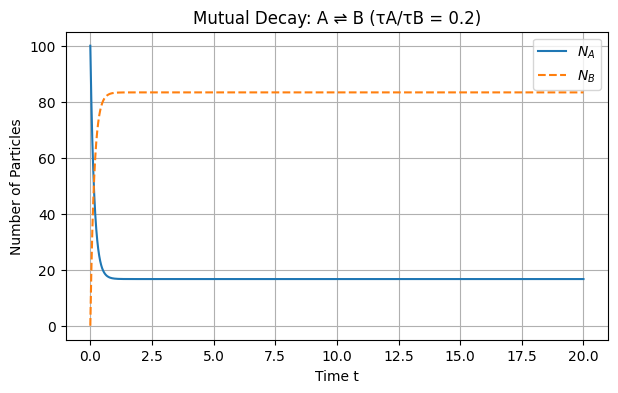

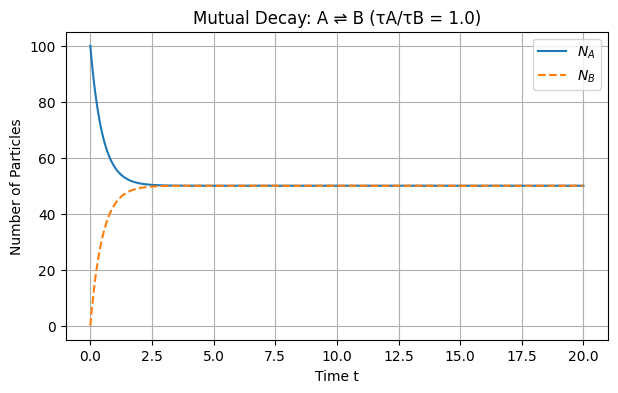

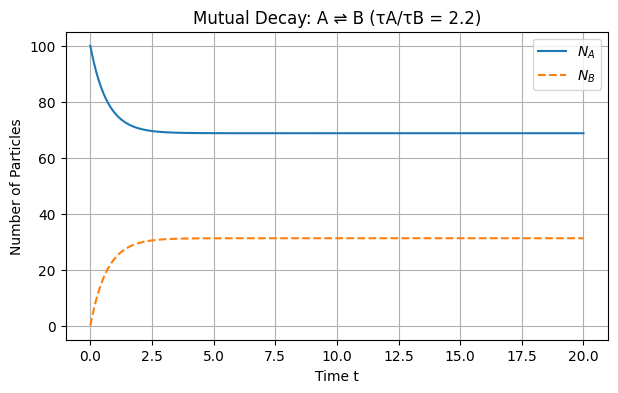

In [ ]:


for r in ratios:
    tauA = r * tauB
    mutual_decay = get_mutual_decay(tauA, tauB)

    solution = euler(mutual_decay, y0, t)
    NA, NB = solution[:,0], solution[:,1]

    plt.figure(figsize=(7,4))
    plt.plot(t, NA, label="$N_A$")
    plt.plot(t, NB, '--', label="$N_B$")
    plt.xlabel("Time t")
    plt.ylabel("Number of Particles")
    plt.title(f"Mutual Decay: A ⇌ B (τA/τB = {r})")
    plt.legend()
    plt.grid(True)
    plt.show()


## Results and Interpretation

### Case 1 : τₐ / τᵦ = 0.2
- Species A decays much faster
- Equilibrium dominated by B
- $N_A$ tends to small value,  $N_B$ tends to large value

### Case τₐ / τᵦ = 1.0
- Symmetric system
- Equal equilibrium number
- $N_A$ = $N_B$ = 50

### Case τₐ / τᵦ = 2.2
- Species A decays slower.
- A dominates at equilibrium

### Conclusion
- The equilibrium populations depend only on τₐ / τᵦ
- Total particle number is conserved throughout


## (b) One-Way Radioactive Decay Chain (A → B → decay)

In this case, the decay process is **not reversible**:

- A decays into B
- B also decays, but **not back into A**

Thus, particles continuously leave the system.

Both species have the same time constant:
$$
\tau = 1
$$

Initial conditions:
$$
N_A(0) = 100, \quad N_B(0) = 0
$$


### Construction of the Rate Equations

#### Change in  $N_A$

Species A only **loses particles** due to decay into B.

Since each A particle decayse  $1/\tau$ :

$$
\frac{dN_A}{dt} = -\frac{N_A}{\tau}
$$

#### Change in  $N_B$
Species B:
- Gains particles from A → B
- Loses particles due to its own decay

Hence:

$$
\frac{dN_B}{dt} = \frac{N_A}{\tau} - \frac{N_B}{\tau}
$$



## Analytical Solution

### Solution for  $N_A$(t)

The equation for A is independent:

$$
\frac{dN_A}{dt} = -N_A
$$

Solving:

$$
N_A(t) = 100 e^{-t}
$$

### Solution for $N_B$(t)

Substitute $N_A$(t) into the equation for B:

$$
\frac{dN_B}{dt} = 100 e^{-t} - N_B
$$

This is a linear first-order ODE. Solving gives:

$$
N_B(t) = 100 t e^{-t}
$$

### <u> Asymptotic Behavior</u>

As t tends to infinity :

$$
N_A(t) \to 0
$$
$$
N_B(t) \to 0
$$

Thus, **both species vanish asymptotically**.


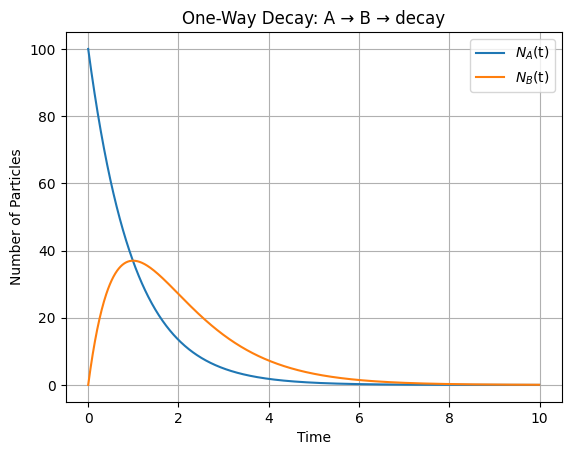

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.01
t = np.arange(0, 10, dt)

NA = np.zeros(len(t))
NB = np.zeros(len(t))

NA[0] = 100
NB[0] = 0

for i in range(len(t)-1):
    NA[i+1] = NA[i] + dt * (-NA[i])
    NB[i+1] = NB[i] + dt * (NA[i] - NB[i])

plt.plot(t, NA, label="$N_A$(t)")
plt.plot(t, NB, label="$N_B$(t)")
plt.xlabel("Time")
plt.ylabel("Number of Particles")
plt.title("One-Way Decay: A → B → decay")
plt.legend()
plt.grid()
plt.show()


## Comparison of Cases (a) and (b)

### Case (a): A ⇌ B

- The system is **closed**
- Particles only transform between A and B
- Total number is conserved:
  $$
  N_A + N_B = \text{constant}
  $$
- A balance is established between forward and reverse decay
- The system reaches a **non-zero equilibrium**

### Case (b): A → B → decay

- The system is **open**
- Particles continuously leave the system
- No reverse process exists
- Total number decreases with time:
  $$
  N_A + N_B \to 0
  $$



So we analyzed the dynamics of two radioactive species, $N_A$ and $N_B$, under two scenarios using Euler’s method. In part (a), where $N_A$ decays into $N_B$ and $N_B$ decays back into $N_A$, the total number of particles remains constant, and the ratio $\tau_A / \tau_B$ determines how quickly each species converts relative to the other; the system eventually reaches a non-zero equilibrium because particles are only interchanging without loss. In part (b), where $N_A$ decays into $N_B$ and $N_B$ also decays without converting back, both populations decrease over time and eventually approach zero, since particles are lost from the system.